In [ ]:
import logging
import sys
from pathlib import Path

import dotenv

dotenv.load_dotenv("../../.env")

from workloads.workload_provider_bff import BFFWorkload

sys.path.append(Path.cwd().parent.parent.as_posix())

from observability.logging.logger import setup_logging
from observability.logging.wandb_api_helper import wandb_retrieve_metrics_for_run

# setup logger
setup_logging(logging.DEBUG)


file_path = "/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/"
# wandb_runs = ["m67to2p5"]  # optim
wandb_runs = [
    (BFFWorkload.TPCH_ST, "8of99wia"),
    # ("tpch", "tc2q4e36 "),  # TPCH mt
    # ("ceb", "2h03uj74"),  # CEB mt
    # ("tpch", "3zdiw9ol "),  # TPCH optim
    # ("ceb", "gava9bsh"),  # CEB mt
]  # mt

# lookup snapshot for wandb run
if wandb_runs is not None:
    snapshot_hash = []
    for benchmark, wandb_run in wandb_runs:
        statistics, config, hist = wandb_retrieve_metrics_for_run(
            benchmark=benchmark,
            run_id=wandb_run,
            output_hist=True,
            entity="learneddb",
            project="BespokeFF",
        )
        snapshot_hash.append(statistics["code/snapshot_hash"])
else:
    snapshot_hash = None

print(f"snapshot hash: {snapshot_hash}")


✓ Run loaded: tpch_st_base_q1-8_openai-unsloth-MiniMax-M3_ssd_bstorage
  State: failed
  Created: 2026-06-25T18:09:42Z
✓ Data fetched: 1436 turns, 108 columns
snapshot hash: ['b67899553d1095f208eb9c2dddc013b3ec752570']


In [8]:
import pandas as pd


def file_matches(observed_set: set, expected_set: set | None):
    if expected_set is None:
        return True

    # check if there is overlap between sets
    if observed_set.intersection(expected_set):
        return True

    return False


def get_matching_files(
    sf_list,
    threads_list,
    benchmarks,
    systems,
    snapshot_hash: list[str] | None,
    hostname: str | None,
):
    matching_files = []
    for file in sorted(Path(file_path).glob("*.csv")):
        # load the file to pandas dataframe
        df = pd.read_csv(file)

        # check if any of the conditions hold
        sf_in_file = df["scale_factor"].unique().tolist()
        t_in_file = df["num_threads"].unique().tolist()
        b_in_file = df["benchmark"].unique().tolist()
        s_in_file = df["system"].unique().tolist()
        snapshot_in_file = df["snapshot"].dropna().unique().tolist()
        hostname_in_file = df["hostname"].unique().tolist()

        if not file_matches(set(sf_in_file), set(sf_list)):
            print(f"File {file} does not match sf condition: {sf_in_file} vs {sf_list}")
            continue

        if not file_matches(set(t_in_file), set(threads_list)):
            print(
                f"File {file} does not match threads condition: {t_in_file} vs {threads_list}"
            )
            continue

        if not file_matches(set(b_in_file), set(benchmarks)):
            print(
                f"File {file} does not match benchmark condition: {b_in_file} vs {benchmark}"
            )
            continue

        if not file_matches(set(s_in_file), set(systems)):
            print(
                f"File {file} does not match system condition: {s_in_file} vs {systems}"
            )
            continue

        if len(snapshot_in_file) != 0:
            if snapshot_hash is not None and not file_matches(
                set(snapshot_in_file), set(snapshot_hash)
            ):
                print(
                    f"File {file} does not match snapshot condition: {snapshot_in_file} vs {snapshot_hash}"
                )
                continue

        if hostname is not None and not file_matches(
            set(hostname_in_file), set([hostname])
        ):
            print(
                f"File {file} does not match hostname condition: {hostname_in_file} vs {hostname}"
            )
            continue
        elif hostname is None:
            found_ctr = 0
            for h in hostname_in_file:
                if h.startswith("fn"):
                    found_ctr += 1

            if found_ctr == 0:
                print(
                    f"File {file} does not match hostnames starting with fn: {hostname_in_file}"
                )
                continue

        matching_files.append(file)
    return matching_files


benchmarks = ["tpch_st"]
systems = ["DuckDB", "Clickhouse", "Umbra", "Bespoke"]

sf_plot = True

if sf_plot:
    sf_list = [1, 2, 20]
    threads_list = [1, 16]
else:
    # threads plot
    sf_list = [5, 10, 50, 100]
    threads_list = [2, 4, 8, 32]
# hostname = "fn02"
hostname = None

matching_files = get_matching_files(
    sf_list=sf_list,
    threads_list=threads_list,
    benchmarks=benchmarks,
    systems=systems,
    snapshot_hash=snapshot_hash,
    hostname=hostname,
)

print("Matching files:")
for file in matching_files:
    print(file)

File /mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260625_204246_duckdb_tpch_st.csv does not match sf condition: [500, 1000] vs [1, 2, 20]
File /mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260626_065351_bespoke_tpch_st.csv does not match sf condition: [] vs [1, 2, 20]
File /mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260626_065503_bespoke_tpch_st.csv does not match sf condition: [] vs [1, 2, 20]
Matching files:
/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260625_195628_duckdb_tpch_st.csv
/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260626_065649_bespoke_tpch_st.csv


In [3]:
# # assemble cmd
# cmd = (
#     "python -m demo_and_analysis.benchmark plot "
#     + " ".join(str(f) for f in matching_files)
#     + " --output plots/plot.png --x scale_factor"
# )
# print("Run the following command to generate the plot:")
# print(cmd)

2026-06-26 07:01:47 INFO:observability.benchmark.plot:Plotting benchmark logs: [PosixPath('/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260625_195628_duckdb_tpch_st.csv'), PosixPath('/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260626_065649_bespoke_tpch_st.csv')]
2026-06-26 07:01:47 INFO:observability.benchmark.plot:Wrote benchmark plot to /home/jwehrstein/Retreat26BespokeFileFormats/observability/benchmark/plots/plot_sf.pdf


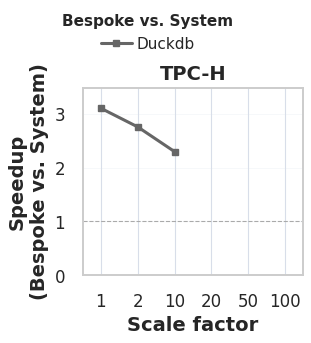

In [10]:
import importlib
from types import SimpleNamespace

import observability.benchmark.plot
import observability.benchmark.plot_by_threads

importlib.reload(observability.benchmark.plot_by_threads)
importlib.reload(observability.benchmark.plot)

plot_args = {
    "logs": matching_files,
    "output": Path().cwd() / "plots" / "plot_sf.pdf",
    "x": "scale_factor",
    # "title": "TPC-H Speedup by Scalefactor",
    "thread_plot_args": {
        "show_speedup": True,
        "product_plot": True,
        "threads_to_show": [1],
        "show_value_labels": False,
    },
}

# convert to namespace
plot_args_ns = SimpleNamespace(**plot_args)

fig = observability.benchmark.plot.plot_logs(plot_args_ns, show=True)
assert fig is not None, "Plotting failed, fig is None"

fig.show()

2026-06-25 20:11:51 INFO:observability.benchmark.plot:Plotting benchmark logs: [PosixPath('/mnt/labstore/jwehrstein/bespoke_ff/benchmark_logs/20260625_195628_duckdb_tpch_st.csv')]
2026-06-25 20:11:51 INFO:observability.benchmark.plot:Wrote benchmark plot to /home/jwehrstein/Retreat26BespokeFileFormats/observability/benchmark/plots/plot_num_threads.pdf



tpch_st  [total time (s)]
                      1
---------------  ------
Duckdb (SF 1)      1.01
Duckdb (SF 10)     9.54
Duckdb (SF 100)  102.27
Duckdb (SF 2)      1.92
Duckdb (SF 20)    18.64
Duckdb (SF 50)    50.76


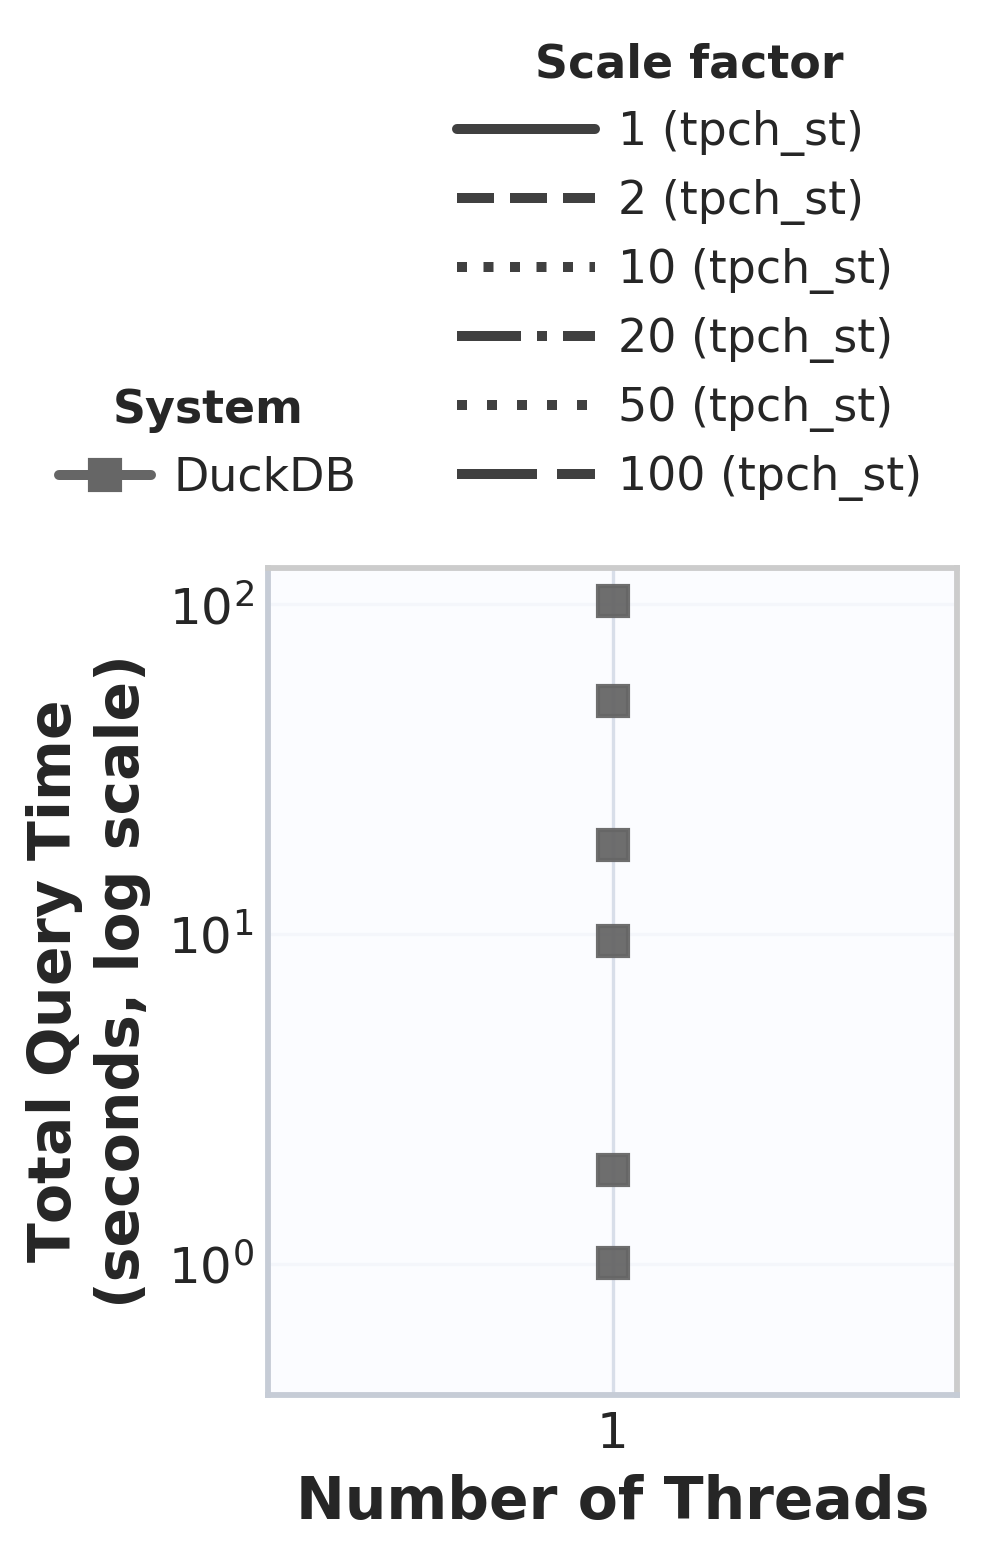

In [10]:
import importlib
from types import SimpleNamespace

import observability.benchmark.plot
import observability.benchmark.plot_by_threads

importlib.reload(observability.benchmark.plot_by_threads)
importlib.reload(observability.benchmark.plot)

from observability.benchmark.plot import plot_logs

plot_args = {
    "logs": matching_files,
    "output": Path().cwd() / "plots" / "plot_num_threads.pdf",
    "x": "num_threads",
    # "title": "TPC-H Speedup by Threads",
    "thread_plot_args": {
        "show_speedup": False,
        "show_runtime": True,
        "max_threads": 64,
        "legend_pos": "up",
        "product_plot": True,
    },
}

# convert to namespace
plot_args_ns = SimpleNamespace(**plot_args)

fig = plot_logs(plot_args_ns, show=True, print_values=True)
assert fig is not None, "Plotting failed, fig is None"

fig.show()